# Analysis of Supergravity Potential in 2511.02981

The notebook below provides code supporting the manuscript.

The gradient descent to sample the moduli space is omitted because it is very computationally intensive.
Instead, we provide a sample of results in an accompanying `Points_5d.npy`

In [8]:
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import HDBSCAN

from ASMC import SparsePolynomialSampler, utils

In [2]:
# Config
colors = [[0.1,0.3,0.45],[0.65,0.35,0],[0.5,0.0,0.13],[0.08,0.48,0.31],[0.75,0.36,0.51],[0.99,0.86,0.18],[1.0,0.84,0.64]]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 20
})

In [3]:
# Load points obtained from gradient descent
x_5d = np.load('Points_5d.npy')

## Analysis of Gradient Descent

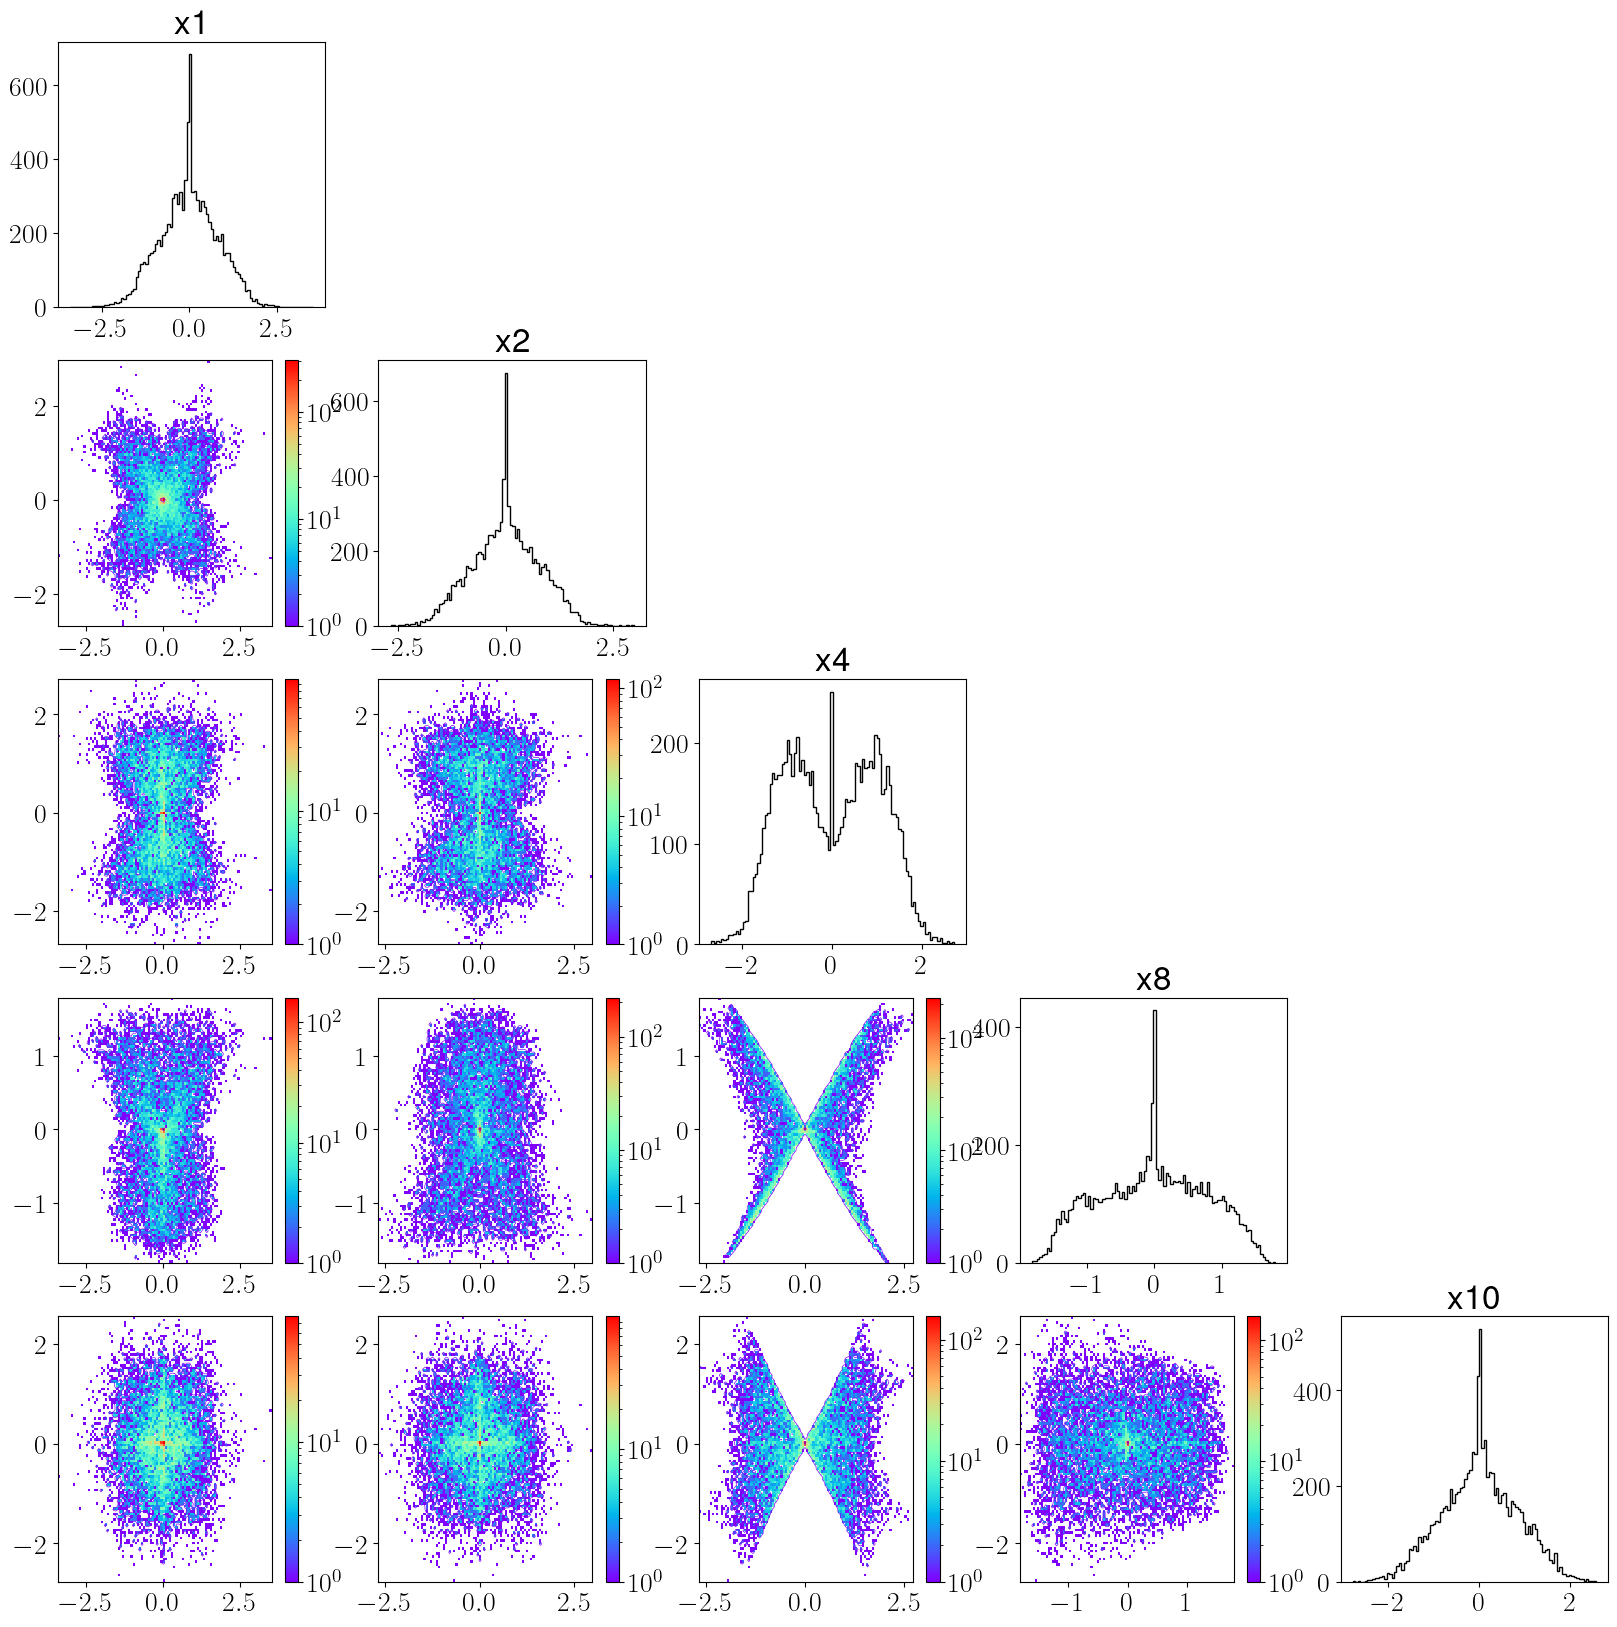

In [ ]:
# Inspection of conformal manifold
utils.triangular_plot(x_5d,figsize=(20,20),names=['x1','x2','x4','x8','x10'])

## Local Analysis

In [ ]:
# Computation of local dimensions using KD-Tree
loc_dim_diff_nneig = []
all_n_neig = [5,10,20,50]

for i in all_n_neig:
    print(i)
    loc_dim = utils.local_dim_n_points(x_5d,
                             verbose=1,
                             n_neig=i,
                             n_jobs=4)
    loc_dim_diff_nneig.append(loc_dim)

5
Searching for neighbors using KD-Tree...
Computing the local dimensions...
Computation finished!
10
Searching for neighbors using KD-Tree...
Computing the local dimensions...
Computation finished!
20
Searching for neighbors using KD-Tree...
Computing the local dimensions...
Computation finished!
50
Searching for neighbors using KD-Tree...
Computing the local dimensions...
Computation finished!


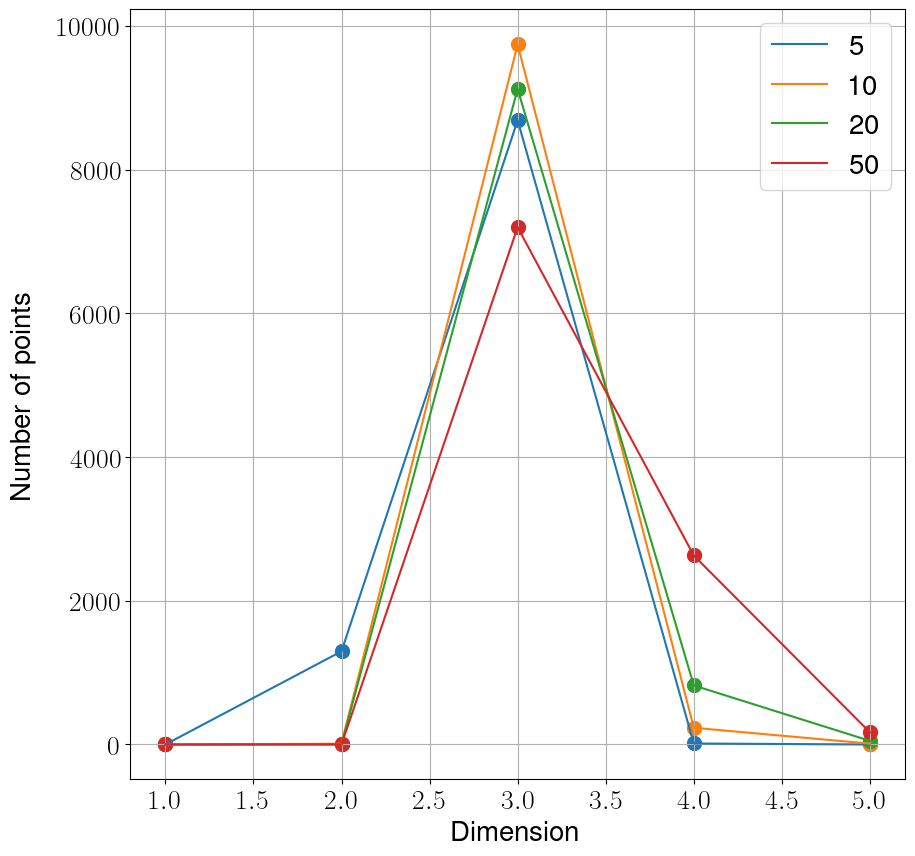

In [7]:
all_dim = []
for i in range(len(all_n_neig)):
    all_dim.append([np.sum(np.array(loc_dim_diff_nneig[i])[:,0]==k) for k in range(1,6)])


plt.figure(figsize=(10, 10))
for i in range(len(all_n_neig)):
    plt.plot(range(1,6),np.array(all_dim[i]),label=str(all_n_neig[i]))
    plt.scatter(range(1,6), np.array(all_dim[i]), s=100)
plt.xlabel("Dimension")
plt.ylabel("Number of points",labelpad=15)
plt.legend()
plt.grid()
plt.show()

## Clustering 

In [10]:
all_local_dim_5d = np.array(loc_dim_diff_nneig)[2][:,0] 
x_5d_deco = x_5d[np.array(all_local_dim_5d)==3]

In [ ]:
clusterer = HDBSCAN(min_cluster_size=10, copy=False)
labels = clusterer.fit_predict(x_5d_deco)

In [34]:
for lab_idx in range(np.max(labels)+2):
    print(x_5d_deco[labels==lab_idx-1].shape)

(1583, 5)
(7525, 5)
(17, 5)


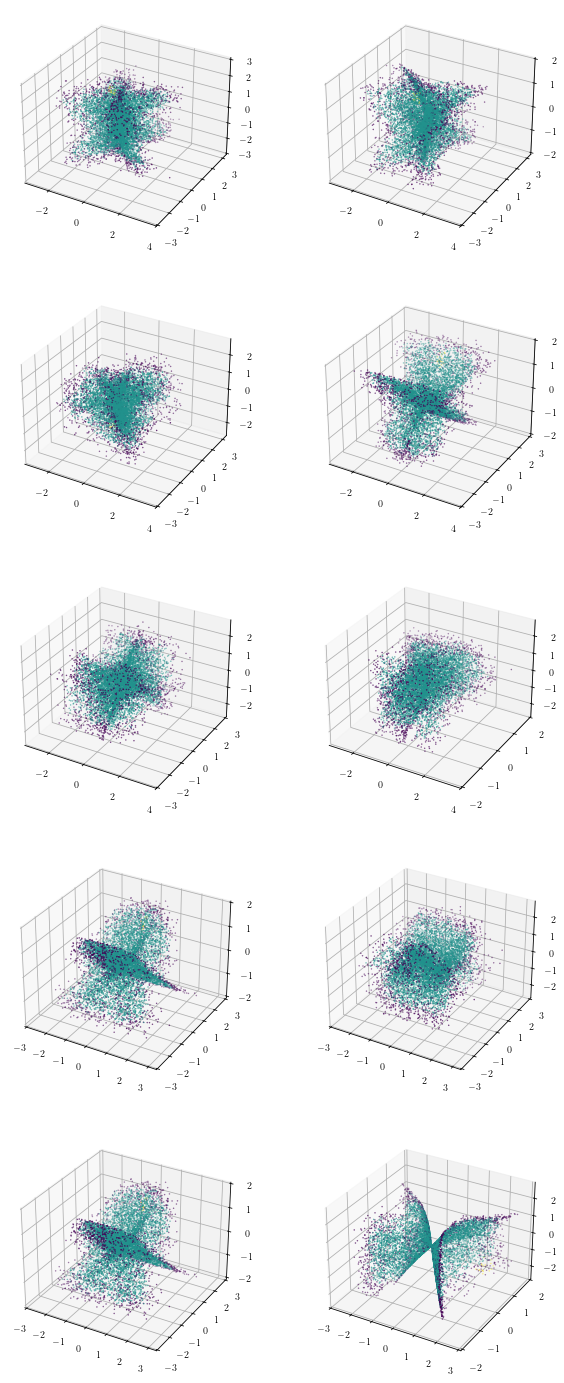

In [ ]:
fig, axes = plt.subplots(5, 2, subplot_kw={'projection': '3d'}, figsize=(10, 25))

axes[0,0].scatter(x_5d_deco[:,0],x_5d_deco[:,1],x_5d_deco[:,2],c=labels, cmap="viridis",s=0.2)
axes[0,1].scatter(x_5d_deco[:,0],x_5d_deco[:,1],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[1,0].scatter(x_5d_deco[:,0],x_5d_deco[:,1],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[1,1].scatter(x_5d_deco[:,0],x_5d_deco[:,2],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[2,0].scatter(x_5d_deco[:,0],x_5d_deco[:,2],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[2,1].scatter(x_5d_deco[:,0],x_5d_deco[:,3],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[3,0].scatter(x_5d_deco[:,1],x_5d_deco[:,2],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[3,1].scatter(x_5d_deco[:,1],x_5d_deco[:,2],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[4,0].scatter(x_5d_deco[:,1],x_5d_deco[:,2],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[4,1].scatter(x_5d_deco[:,2],x_5d_deco[:,3],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
plt.show()

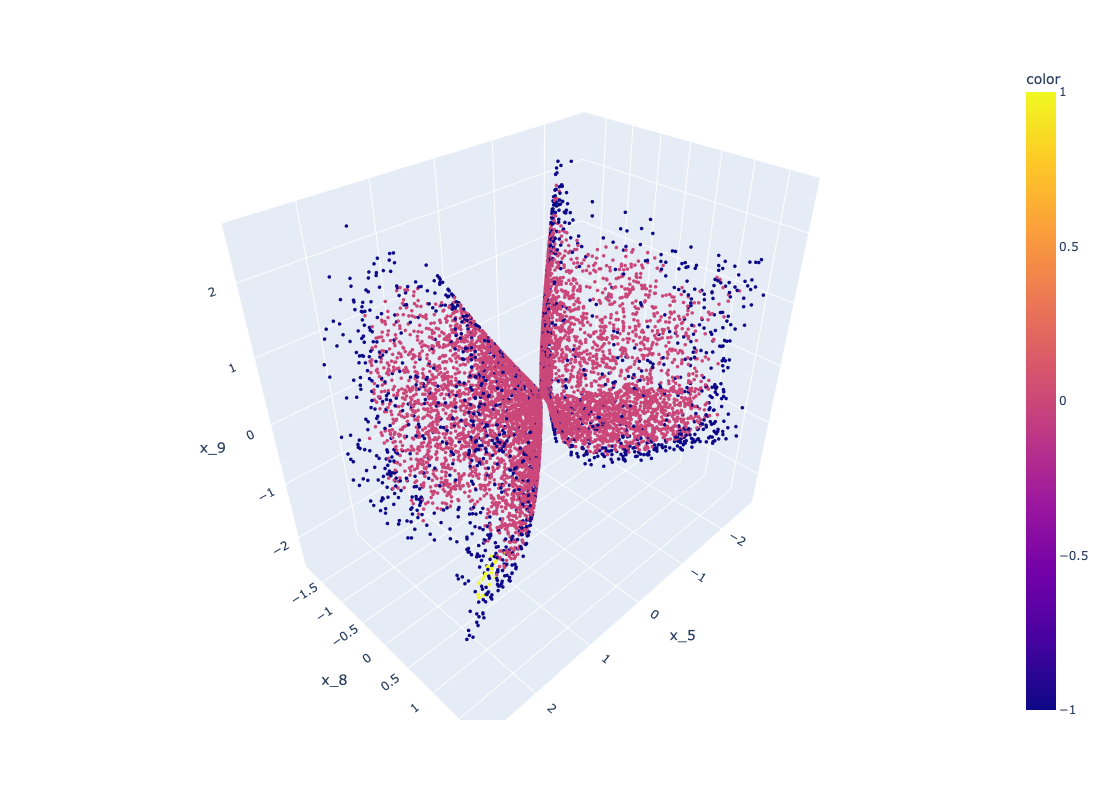

In [ ]:
# Scatter plot
fig = px.scatter_3d(x=x_5d_deco[:,2], y=x_5d_deco[:,3], z=x_5d_deco[:,4], 
                    color=labels, labels={'x':'x_4', 'y':'x_8', 'z':'x_10'})
fig.update_layout(width=1000, height=800)
fig.update_traces(marker=dict(size=2)) 

fig.update_layout(scene=dict(xaxis_title='x_5', yaxis_title='x_8', zaxis_title='x_9'))
fig.show()

## ASMC Fitting

In [14]:
my_data_raw = np.load("./Points_5d.npy")

my_data_x = np.array([my_data_raw[:,0],
                     my_data_raw[:,1],
                     my_data_raw[:,2],
                     np.exp(my_data_raw[:,3]),
                     my_data_raw[:,4]]).T

In [15]:
sampler = SparsePolynomialSampler(
    data_x=my_data_x,
    max_degree=5,
    num_vars=5,
    max_num_monomials=5,
    prob_add= lambda i,n_iter: 0., 
    prob_remove= lambda i,n_iter: 0., 
    prob_modify= lambda i,n_iter: 0.5, 
    prob_multiply= lambda i,n_iter: 0.25, 
    prob_divide= lambda i,n_iter: 0.25, 
    regularisation_factor=1e3,
    sigma_proposal = lambda i,n_iter: 0.1,
    )

Pre-compute multiply/divide transitions...
  Average of multiply transitions: 2.50
  Average of divide transitions: 2.50
Number of possible terms in the polynomial: 252


In [16]:
all_out = sampler.run_annealing_is(
    n_iter=1000,       
    n_particles=1000,  
    verbose=True,
    adaptative_temp=True,
    degree_bias=0.,
    sparsity_factor=0.,
    adaptation_strength=lambda i,n_iter : 0.05,
    target_acc_rate = lambda x,y : 0.8 - 0.5 * x/y,
    beta_schedule=lambda i,n_iter: 1e-10
)

Iteration 1/1000, 	Beta: 1e-10, 	Acceptance rate: 1.00, 	ESS: 1000.00/1000, 	Best loss: 9645.475798,	Elapsed time: 0.96s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 0.3669*x2*x4 + 0.3709*x1*x2^2 + 0.1030*x1*x2*x3*x5^2 + 0.3163*x1^2*x2*x3*x5 + 0.1920*x1^2*x2^2*x5
Iteration 2/1000, 	Beta: 1.1e-10, 	Acceptance rate: 1.00, 	ESS: 999.99/1000, 	Best loss: 9426.911905,	Elapsed time: 1.22s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 0.3375*x2*x4 + 0.3709*x1*x2^2 + 0.1030*x1*x2*x3*x5^2 + 0.3163*x1^2*x2*x3*x5 + 0.1920*x1^2*x2^2*x5
Iteration 3/1000, 	Beta: 1.1e-10, 	Acceptance rate: 1.00, 	ESS: 999.98/1000, 	Best loss: 9264.402243,	Elapsed time: 1.45s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 0.3375*x2*x4 + 0.3709*x1*x2^2 + 0.3163*x1^2*x3*x5 + 0.1030*x1*x2*x3*x5^2 + 0.1920*x1^2*x2^2*x5
Iteration 4/1000, 	Beta: 1.2e-10, 	Acceptance rate: 1.00, 	ESS: 999.94/1000, 	Best loss: 9089.792331,	Elapsed time: 1.69s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 0.3375*x2*x4 + 0.3709*x1*x2^2 

In [17]:
best_coeffs = all_out[0]
bc_trunc = sampler.apply_coefficient_threshold(best_coeffs)
print(sampler.evaluate_polynomial_batch(np.array([bc_trunc])))

res, loss = sampler.local_search(best_coeffs,n_steps=1000,use_reg=False)
print(loss)

[34.00362319]
[0.00285273]


In [18]:
sampler.polynomial_to_string(res)
sampler.min_coeff_threshold = 1e-3
res_trunc = sampler.apply_coefficient_threshold(res)
nonzero_indices = np.nonzero(res_trunc)
coeff_min = np.min(abs(res_trunc[nonzero_indices]))

print(sampler.polynomial_to_string(res_trunc/coeff_min))

-1.9972*x2 + 1.9969*x2*x4 - 1.4140*x1*x5 - 1.9979*x1*x3 + x2*x4*x5^2
